# 00 · Quickstart — usar a pipeline e os modelos

Notebook de **uso** (não é um estudo): mostra, de ponta a ponta, como
1. rodar a **pipeline completa** de detecção;
2. **puxar dados** de uma janela de tempo nova;
3. usar os **modelos treinados** para **inferência** nessa janela;
4. **visualizar** as anomalias detectadas.

Cada passo mostra a chamada em Python **e** o script/CLI equivalente. A lógica vive em `src/`;
os scripts em `scripts/` são atalhos finos. Pré-requisito: modelos em `models/` (rode
`python -m src --train` uma vez, ou `notebooks/03_train.ipynb`).

## Setup

In [1]:
# Colab: !git clone https://github.com/Cerne17/NeuraTrade.git ; %cd NeuraTrade ; !pip install -e .
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import CONFIG, set_seeds
set_seeds()
TICKERS = CONFIG["tickers"]
print("tickers:", TICKERS)
print("agregação do erro:", CONFIG["detection"]["aggregation"], "| limiar p95 + dinâmico 252")

tickers: ['PETR4.SA', 'VALE3.SA', 'AMER3.SA', 'ITUB4.SA']
agregação do erro: max | limiar p95 + dinâmico 252


## 1. Pipeline completa

`run_pipeline` encadeia tudo (dados → pré-processamento → carrega/treina modelo → detecção
estática e dinâmica → avaliação sintética) para os quatro ativos, usando a config atual.

**Equivalente na linha de comando:** `python -m src` (ou `python -m src --train` na 1ª vez).

In [2]:
from src.pipeline import run_pipeline, summarize

resultados = run_pipeline(train=False, evaluate=True)   # train=True se não houver modelos salvos
summarize(resultados)

,agregacao,n_test_windows,limiar_estatico,frac_estatico,frac_dinamico,precision,recall,f1
ticker,,,,,,,,
PETR4.SA,max,1215,0.40772,0.0584,0.0568,0.768,0.133,0.227
VALE3.SA,max,1215,0.2631,0.028,0.0856,0.934,0.537,0.682
AMER3.SA,max,1215,0.2844,0.27,0.1251,0.847,0.559,0.674
ITUB4.SA,max,1215,0.37819,0.056,0.0543,0.821,0.174,0.287


## 2. Puxar dados de uma janela nova

`fetch_window` baixa OHLCV das tickers para um intervalo arbitrário (aqui, 2025) **sem tocar** no
cache de treino `data/raw/`.

**Equivalente:** `python scripts/fetch_window.py --start 2025-01-01 --end 2025-06-30`

In [3]:
from src.inference import fetch_window

START, END = "2025-01-01", "2025-06-30"
janela = fetch_window(TICKERS, START, END)        # baixa da rede (yfinance)
for t, df in janela.items():
    print(f"{t}: {len(df)} pregões  ({df.index.min().date()} → {df.index.max().date()})")
janela["PETR4.SA"].tail(3)

PETR4.SA: 121 pregões  (2025-01-02 → 2025-06-27)
VALE3.SA: 121 pregões  (2025-01-02 → 2025-06-27)
AMER3.SA: 121 pregões  (2025-01-02 → 2025-06-27)
ITUB4.SA: 121 pregões  (2025-01-02 → 2025-06-27)


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-06-25,28.790348,28.992580,28.689232,28.689232,23127700
2025-06-26,28.817926,29.047734,28.781156,28.919041,17227000
2025-06-27,28.854694,28.909849,28.624886,28.689232,16482100


## 3. Inferência na janela nova

`infer_all` aplica os modelos treinados (em 2010–2019) à janela nova. **Importante (ADR-0001):**
a normalização e o limiar são os do **treino** — não reajustados sobre 2025 —, então "anomalia"
significa *desvio da normalidade aprendida*, não do próprio intervalo.

**Equivalente interativo:** `python scripts/run_inference.py` (pergunta intervalo + ticker).

In [4]:
from src.inference import infer_all

infer = infer_all(TICKERS, START, END, window_data=janela)   # reaproveita os dados já baixados
resumo = pd.DataFrame({
    t: {"janelas": len(df), "anomalias": int(df["anomalia"].sum())}
    for t, df in infer.items()
}).T
print(resumo)
print("\nAMER3 — primeiras janelas anômalas:")
amer = infer["AMER3.SA"]
amer[amer["anomalia"]].head(5)

          janelas  anomalias
PETR4.SA       91          0
VALE3.SA       91          0
AMER3.SA       91         30
ITUB4.SA       91          0

AMER3 — primeiras janelas anômalas:


,erro,limiar,anomalia
Date,,,
2025-03-27,0.565122,0.284398,True
2025-03-28,0.550963,0.284398,True
2025-03-31,0.531864,0.284398,True
2025-04-01,0.550323,0.284398,True
2025-04-02,0.546496,0.284398,True


## 4. Visualizar as anomalias

Erro de reconstrução ao longo da janela nova, com o limiar do treino e os pontos marcados como
anômalos. AMER3 (pós-fraude) destoa da normalidade pré-2020; ativos estáveis ficam abaixo do
limiar.

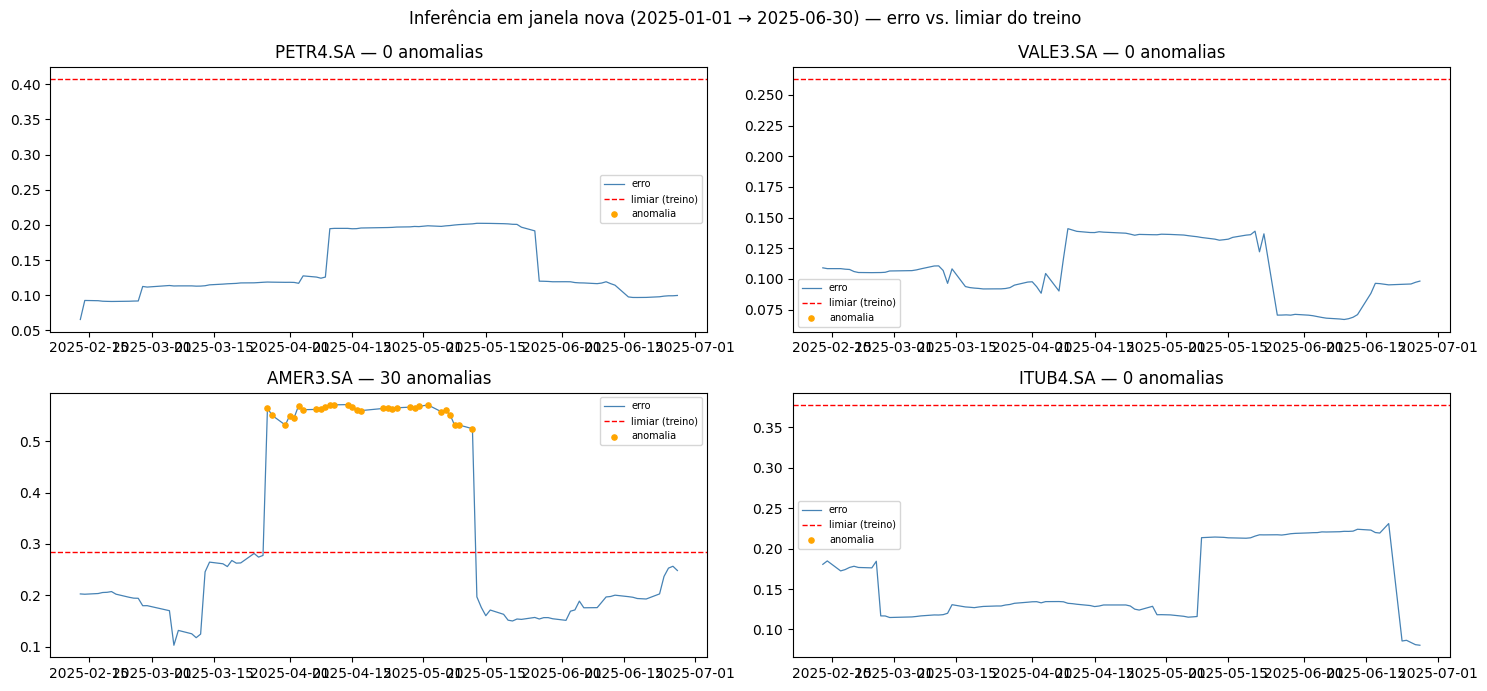

In [5]:
from src.viz import save_fig

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
for ax, t in zip(axes.ravel(), TICKERS):
    d = infer[t]
    ax.plot(d.index, d["erro"], lw=0.9, color="steelblue", label="erro")
    ax.axhline(d["limiar"].iloc[0], color="red", ls="--", lw=1, label="limiar (treino)")
    an = d[d["anomalia"]]
    ax.scatter(an.index, an["erro"], color="orange", s=14, zorder=5, label="anomalia")
    ax.set_title(f"{t} — {int(d['anomalia'].sum())} anomalias")
    ax.legend(fontsize=7)
fig.suptitle(f"Inferência em janela nova ({START} → {END}) — erro vs. limiar do treino")
fig.tight_layout()
save_fig(fig, "quickstart_inferencia_2025")
plt.show()

## 5. Outros utilitários

| Tarefa | Python | Script / CLI |
| --- | --- | --- |
| Pipeline completa | `run_pipeline()` | `python -m src` |
| Treinar do zero | `run_pipeline(train=True)` | `python -m src --train` |
| Baixar janela nova | `fetch_window(...)` | `python scripts/fetch_window.py --start ... --end ...` |
| Inferência interativa | `infer_all(...)` | `python scripts/run_inference.py` |
| Recriar cache de treino | — | `python scripts/cache_data.py` |
| Regenerar figuras | — | `python scripts/build_figures.py` |

> **Notebooks são estudos; este é o guia de uso.** A pipeline de produção é `python -m src`; os
> estudos numerados (01–11) exploram cada decisão (ver `notebooks/README.md`).